In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error

## Assignment 2: $k$ Nearest Neighbor

### Do any four.

## Q1
Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance?
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting?
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

## Q1 Answers
1. Regression predicts a continuous numerical value and classification predicts a discrete categorical label.
2. A confusion matrix is a table that shows the counts of Actual vs Predicted classes that helps us identify where a model is failing.
3. Accuracy is the ratio of correct to total predictions. It is insufficient for imbalanced datasets.
4. Root mean squared error quantifies the average distance between predicted and actual values in a regression model.
5. Overfitting is when a model looks too closely at training data and into patterns that don't exist. Underfitting is when a model doesn't look closely enough and does not capture that patterns it is intended to.
6. Splitting the data allows us to test the model on data it hasn't seen which helps us identify overfitting.
7. Labels are easier to interpret but force the model to make a decision with absolute confidence, while probabilities are harder to interpret but show the model's confidence in its response.

## Q2
This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000


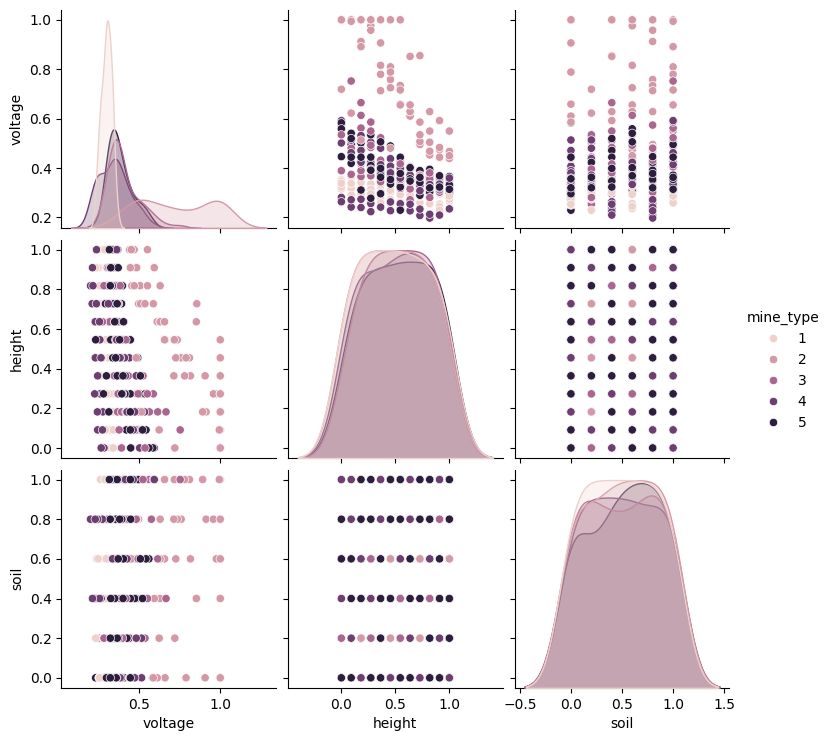

Optimal k: 2
Accuracy: 0.40236686390532544
Confusion Matrix:
 [[17  0 18  2  0]
 [ 0 25  4  4  0]
 [ 8  3 16  2  3]
 [12  5 10  7  2]
 [ 8  2 12  6  3]]


In [6]:
# 1
_df = pd.read_csv('../data/land_mines.csv')
print(_df.describe())
sns.pairplot(_df, hue='mine_type')
plt.show()

# 2
_X = _df.drop('mine_type', axis=1)
_y = _df['mine_type']
_X_train, _X_test, _y_train, _y_test = train_test_split(_X, _y, test_size=0.5, random_state=42)

# 3: I select k by checking for k between 1 and 20 and finding the model that scores best.
_scores = []
for _k in range(1, 20):
    _knn = KNeighborsClassifier(n_neighbors=_k)
    _knn.fit(_X_train, _y_train)
    _scores.append(_knn.score(_X_test, _y_test))

_best_k = _scores.index(max(_scores)) + 1
_model = KNeighborsClassifier(n_neighbors=_best_k).fit(_X_train, _y_train)

# 4: 40% accurate. Performance is more accurate in identifying type 2 mines (25 correct) compared to type 5 (3 correct) or type 4 (7 correct) mines
_y_pred = _model.predict(_X_test)
print(f"Optimal k: {_best_k}")
print(f"Accuracy: {accuracy_score(_y_test, _y_pred)}")
print("Confusion Matrix:\n", confusion_matrix(_y_test, _y_pred))

# 5: Due to the low accuracy of the model, it should not be used as a primary safety tool and instead used as a tool to warn for potential mines.

## Q3
This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

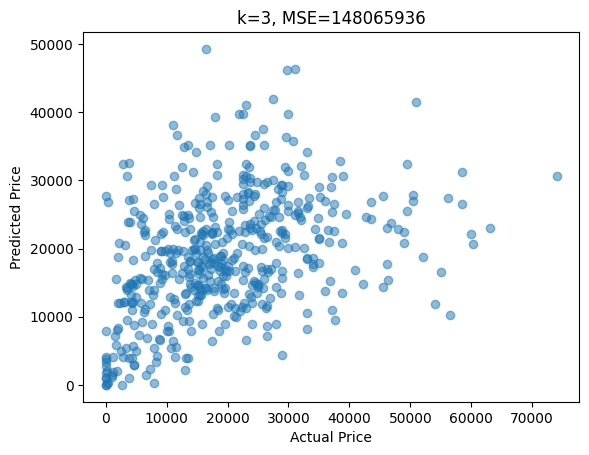

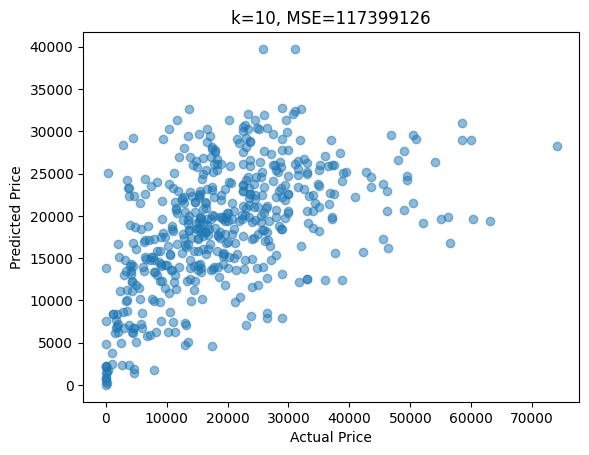

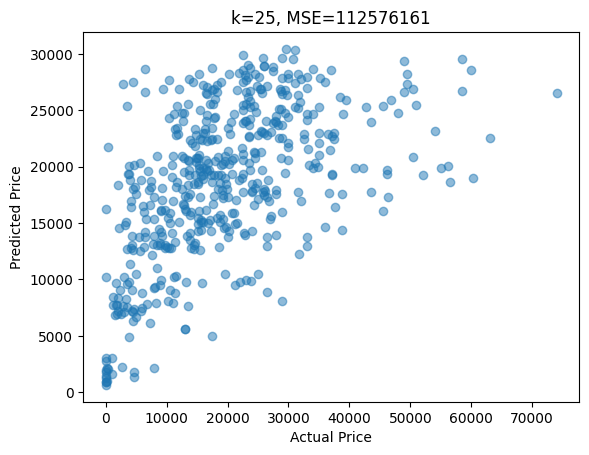

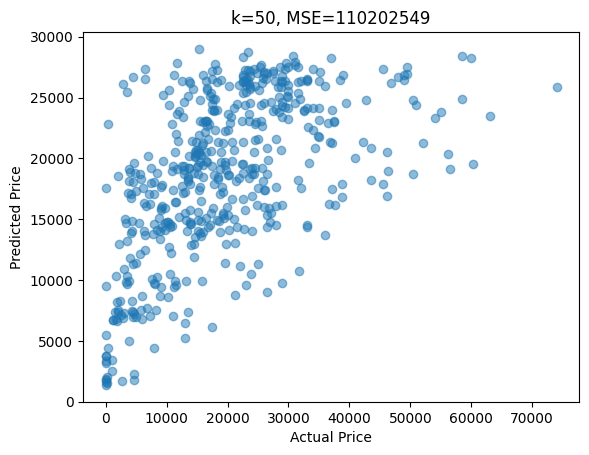

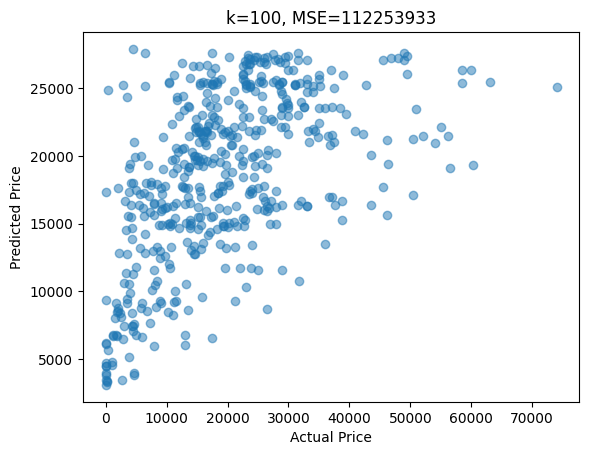

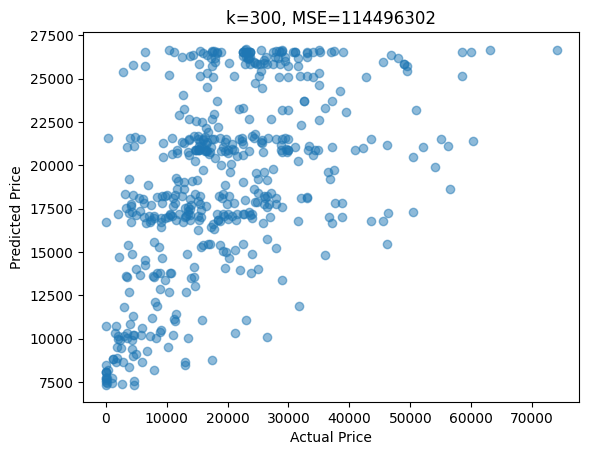

In [7]:
# 1
_df = pd.read_csv('../data/USA_cars_datasets.csv')[['price', 'year', 'mileage']].dropna()

# 2
_X = _df[['year', 'mileage']]
_X_norm = (_X - _X.min()) / (_X.max() - _X.min())
_y = _df['price']

# 3
_X_train, _X_test, _y_train, _y_test = train_test_split(_X_norm, _y, test_size=0.2, random_state=42)

# 4
_ks = [3, 10, 25, 50, 100, 300]
for _k in _ks:
    _knn = KNeighborsRegressor(n_neighbors=_k)
    _knn.fit(_X_train, _y_train)
    _preds = _knn.predict(_X_test)
    _mse = mean_squared_error(_y_test, _preds)

    plt.scatter(_y_test, _preds, alpha=0.5)
    plt.title(f"k={_k}, MSE={_mse:.0f}")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.show()

# 5: The optimal k is 50 since it has the lowest mean squared error.

# 6: At k=3, the model underfitted the training data. As k increased to 50 it began to become more accurate hitting the balance between underfitting and overfitting. At k=300 as k increased past 50, the model overfitted the training data.

## Q6
This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

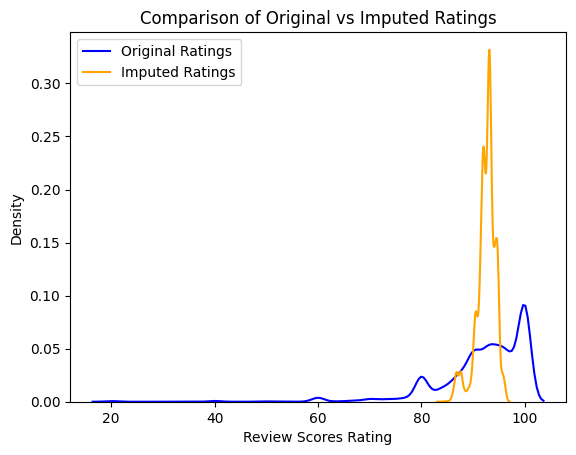

In [8]:
# 1
df = pd.read_csv('../data/airbnb_hw.csv').loc[:, ['Review Scores Rating', 'Price', 'Beds']]
df['Price'] = df['Price'].astype(str).str.replace(',', '', regex=False).astype(float)

# 2
missing = df.loc[df['Review Scores Rating'].isnull()]
missing = missing.dropna(subset=['Price', 'Beds'])

# 3
df = df.dropna(axis=0, how='any')

# 4
X = df[['Price', 'Beds']]
y = df['Review Scores Rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_k = 5
min_mse = float('inf')
for k in range(1, 100, 2):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    err = mean_squared_error(y_test, knn.predict(X_test))
    if err < min_mse:
        min_mse = err
        best_k = k

# 5
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X, y)
imputed_values = final_model.predict(missing[['Price', 'Beds']])

# 6: Both ratings distributions are skewed left toward high ratings, but the original ratings has a wider spread and lower peaks compared to the imputed ratings.
sns.kdeplot(y, label='Original Ratings', color='blue')
sns.kdeplot(imputed_values, label='Imputed Ratings', color='orange')
plt.legend()
plt.title("Comparison of Original vs Imputed Ratings")
plt.show()